In [69]:
import pandas as pd
import requests as re
import matplotlib.pyplot as plt

Which team has the best home court advantage? The graph shows the teams with the highest home win percentage.

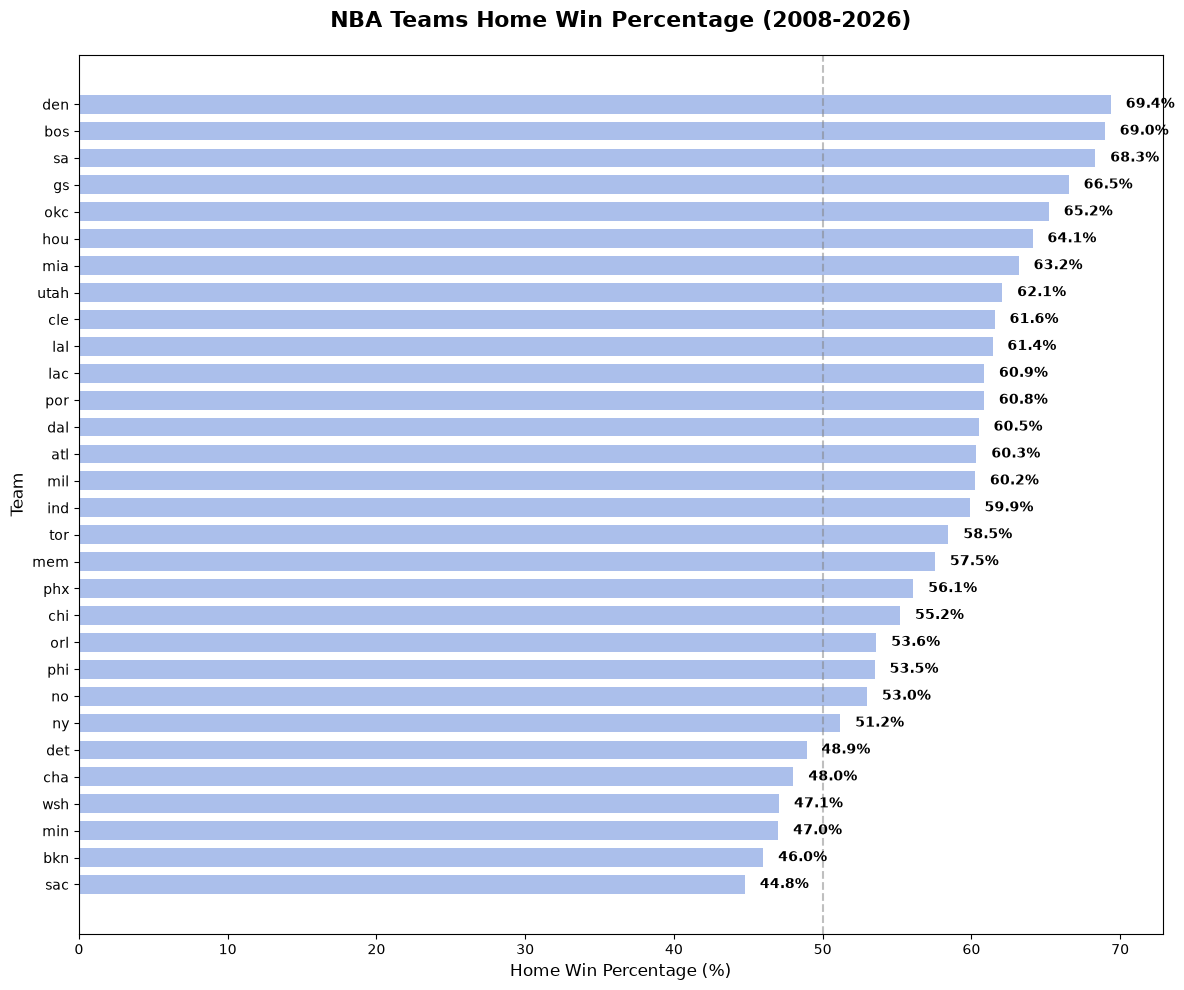

The team with the best home court advantage is the den with a 69.4% home win rate.


In [70]:
#creates a results column with the winner of the game, home or away
hcpd=pd.read_csv("nba_2008-2026.csv")
hcpd["results"]=hcpd["score_home"]>hcpd["score_away"]
hcpd["results"] = hcpd["results"].map({True: "Win", False: "Loss"})
#creates a new dataframe that sorts by homewin percentage
homestats = hcpd.groupby(["home", "results"]).size().unstack(fill_value=0)
homestats["Total_Games"] = homestats["Win"] + homestats["Loss"]
homestats["Home_Win_Pct"] = (homestats["Win"] / homestats["Total_Games"]) * 100
homestatssorted = homestats.sort_values("Home_Win_Pct", ascending=True)
#setting up the parameters and adding details to the graph before adding data
plt.figure(figsize=(12, 10))
bars = plt.barh(homestatssorted.index, homestatssorted["Home_Win_Pct"], color='#ABBFEB', height=0.7)
plt.axvline(50, color='grey', linestyle='--', alpha=0.5) #add dashed line at 50% win rate
#naming the axes
plt.title("NBA Teams Home Win Percentage (2008-2026)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Home Win Percentage (%)", fontsize=12)
plt.ylabel("Team", fontsize=12)
#add each bar with percentage values rounded to one decimal point
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', 
             va='center', ha='left', fontsize=10, fontweight='semibold')
plt.tight_layout()
plt.show() 
#print out data
besthometeam = homestats.sort_values("Home_Win_Pct", ascending=False).index[0]
bestpct = homestats.sort_values("Home_Win_Pct", ascending=False)["Home_Win_Pct"].iloc[0]
print(f"The team with the best home court advantage is the {besthometeam} with a {bestpct:.1f}% home win rate.")

den is the Denver Nuggets

How accurate are game predictions? 

In [71]:
hcpdd=pd.read_csv("nba_2008-2026.csv")
# creates a new dataframe of the rows where the betting odds accurately predicted the result of the game
predictwins = hcpdd[(hcpdd["score_home"]>hcpdd["score_away"])&(hcpdd["whos_favored"]=='home')|(hcpdd["score_home"]<hcpdd["score_away"])&(hcpdd["whos_favored"]=='away')]
print(f'Game predictions are {len(predictwins)/len(hcpdd):.2%} accurate')

Game predictions are 68.40% accurate


How often do large market teams perform better than small market teams?

In [72]:
teams=pd.read_csv("teams.csv")
teams=teams[["TEAM_ID", "CITY", "NICKNAME"]]
games = pd.read_csv("games.csv")
# Merge team names into the games dataframe to identify the home team
games=games.merge(
    teams,
    left_on="TEAM_ID_home",
    right_on="TEAM_ID",
    how="left"
)

# Clean up column names for the home team and drop the unnecessary ID column
games=games.rename(columns={"CITY": "HOME_CITY","NICKNAME": "HOME_TEAM"})
games=games.drop(columns=["TEAM_ID"])

# Merge team names into the games dataframe again to identify the away team
games=games.merge(teams,left_on="TEAM_ID_away",right_on="TEAM_ID",how="left")

# Clean up column names for the away team and drop the redundant ID column
games=games.rename(columns={"CITY": "AWAY_CITY","NICKNAME": "AWAY_TEAM"})
games = games.drop(columns=["TEAM_ID"])

# Define a list of cities categorized as large-market teams
large_markets = [
    "Los Angeles",
    "New York",
    "Chicago",
    "Boston",
    "Philadelphia",
    "Dallas",
    "Houston",
    "San Francisco"
]

# Create booleans showing whether the home and away teams are from large markets
games["HOME_LARGE"]=games["HOME_CITY"].isin(large_markets)
games["AWAY_LARGE"]=games["AWAY_CITY"].isin(large_markets)

# Filter the dataset to only include games where a large market team plays a small market team
matchups=games[games["HOME_LARGE"] != games["AWAY_LARGE"]]

# Counters to track total wins for both market categories
large_market_wins=0
small_market_wins=0

# Loop through every matchup row-by-row to determine who won the game
for _, row in matchups.iterrows():
    # Check if the home team is the large-market team
    if row["HOME_LARGE"]:
        if row["HOME_TEAM_WINS"]==1:
            large_market_wins+=1
        else:
            small_market_wins+=1
    # Handle cases where the away team is the large-market team
    else:
        if row["HOME_TEAM_WINS"]==0:
            large_market_wins+=1
        else:
            small_market_wins+=1

# Calculate the total games played and the overall win percentages for both sides
total_games=large_market_wins+small_market_wins
large_pct=large_market_wins/total_games*100
small_pct=small_market_wins/total_games*100

# Compare total wins and print which market tier had the superior record
if large_market_wins>small_market_wins:
    print(f"Large-market teams performed better.")
else:
    print(f"Small-market teams performed better.")

# Print out the final calculated win percentages formatted to 2 decimal places
print(f"Large-market teams won {large_pct:.2f}% of games against small-market teams.")
print(f"Small-market teams won {small_pct:.2f}% of games against large-market teams.")

Large-market teams performed better.
Large-market teams won 51.56% of games against small-market teams.
Small-market teams won 48.44% of games against large-market teams.


What was the highest scoring NBA season from 2004-2022? The graph shows the increase in points scored over the years since 2003 up until 2022 excluding 2022 because there isnt every game from that season

The highest scoring season was 2021 with 306156 points


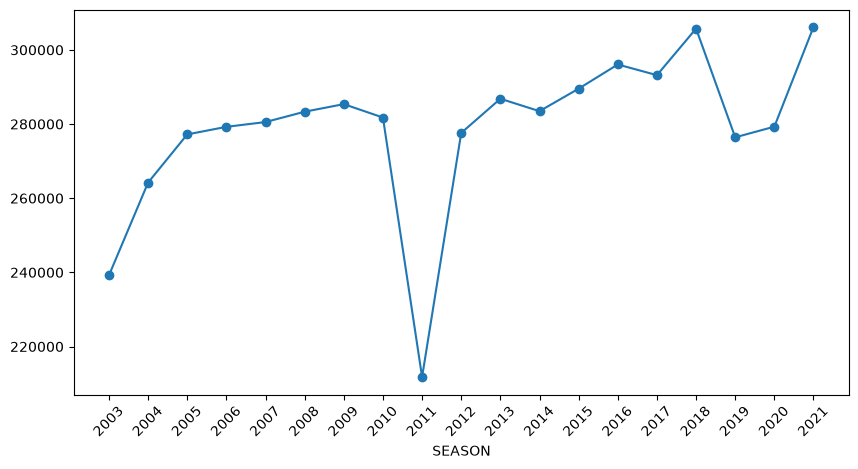

In [73]:
nba_games = pd.read_csv("games.csv")

# Drop team ID columns 
nba_games.drop(columns=["TEAM_ID_home", "TEAM_ID_away"], inplace=True)

# Method to extract the first 4 characters from a date string
def f4(x):
    return x[:4]

# Create a new column for the game's season and calculate the combined score of both teams
nba_games["TOTAL"] = nba_games["PTS_home"] + nba_games["PTS_away"]
#drops 2022
nba_games = nba_games[nba_games["SEASON"] != 2022]
# Group the games by season, sum up all points scored, and sort from highest to lowest
nbasort = nba_games.groupby("SEASON")["TOTAL"].sum().sort_values(ascending=False)
print(f'The highest scoring season was {nbasort.index[0]} with {int(nbasort.iloc[0])} points')
#groups chronologically by year
nbasort = nba_games.groupby("SEASON")["TOTAL"].sum().sort_index()
#creates the plot
ax = nbasort.plot(marker='o', figsize=(10, 5))
# Force the x-axis to only show the integers
ax.set_xticks(nbasort.index)
plt.xticks(rotation=45) 

plt.show()

What team does best when they are favored to lose?

In [74]:
nba_betting = pd.read_csv("nba_2008-2026.csv")
# Drop unnecessary columns to clean up the DataFrame and save memory
nba_betting = nba_betting.drop(columns = ["moneyline_away", "moneyline_home", "h2_spread", "h2_total", "id_spread", "id_total", "q1_away", "q2_away", "q3_away", "q4_away", "ot_away", "q1_home", "q2_home", "q3_home", "q4_home", "ot_home", "spread", "total"])
# method to determine the actual team name of the betting favorite
def fav(away, home, favorite):
    if favorite == "home":
        return home
    return away

#method to determine the team that won the game based on final scores
def win(away, home, sa, sh):
    if(sh>sa):
        return home
    return away

# method to identify an upset, returning the winning underdog's name or "none"
def stun(favor, champ):
    if champ != favor:
        return champ
    return "none"

# Apply the helper functions row-by-row to create new tracking columns
nba_betting["favorite"] = nba_betting.apply(lambda row: fav(row["away"], row["home"], row["whos_favored"]), axis=1)
nba_betting["winner"] = nba_betting.apply(lambda row: win(row["away"], row["home"], row["score_away"], row["score_home"]), axis=1)
nba_betting["upset"] = nba_betting.apply(lambda row: stun(row["favorite"], row["winner"]), axis=1)

# Filter out the "none" values so we only count rows where an actual upset occurred
real_upsets = nba_betting[nba_betting["upset"] != "none"]

# Count the upsets per team and use .head(30) to get the highest counts at the top
upsetcounts = real_upsets["upset"].value_counts().head(30)

# Print the team with the highest number of underdog victories
print(f'The team with the most upsets is {upsetcounts.index[0]} with {upsetcounts.iloc[0]} upsets')

The team with the most upsets is wsh with 304 upsets


wsh is the Washington Wizards

How much does home court advantage change a team’s odds to win?

In [75]:
# Exclude bubble year since it is an outlier
games = hcpd[hcpd["season"] != 2020]
# Getwinner method returns a string of the winner
def get_winner(home, away):
    if home >= away:
        return "home"
    return "away"
# Winner column adds the winner home or away
games["winner"] = games.apply(lambda x: get_winner(x["score_home"], x["score_away"]), axis=1)
# Separate dataframe of games where the winner was the home team
home_wins = games[games["winner"] == "home"]
print(f"The home team has a {len(home_wins) / len(games):.2%} chance of winning")

The home team has a 58.17% chance of winning


How long do teams usually tank?
The first graph compares NBA teams' early season winning percentages against their late-season winning percentages, using red dots to highlight the specific team-seasons flagged as "tanking" due to a severe performance drop-off (losing later in the season compared to their early performance) or an extremely low late-season win rate.
The second graph displays the total number of seasons each franchise has been flagged for tanking 

3.70% of teams have tanked


<Axes: title={'center': 'Team Name vs Years Tanking'}, xlabel='Team Name', ylabel='Years Tanking'>

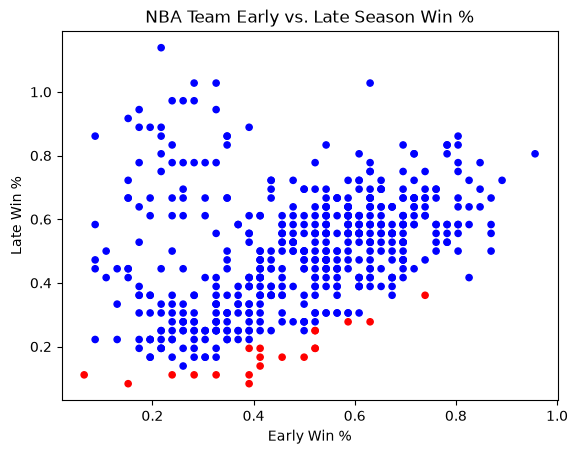

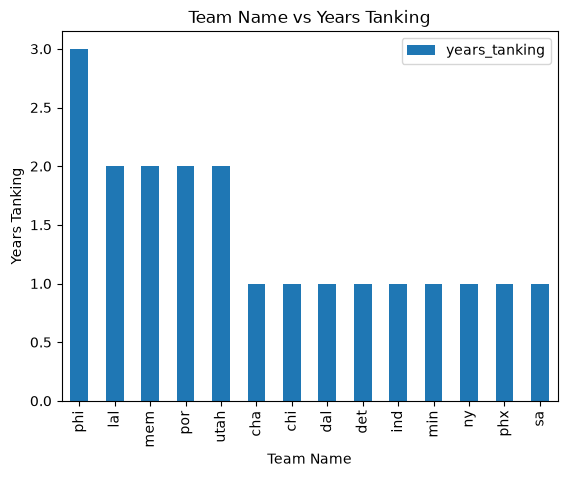

In [76]:
# Method to return the actual team name of the winner
def get_name(winner, home, away):
    if winner == "home":
        return home
    return away

# Method to flag games played between February and September (late season)
def is_late(st):
    month = int(st.split("-")[1])
    return month >= 2 and month < 10

# Map winner names to rows and flag whether each game was played late in the season
games["winner_name"] = games.apply(lambda x: get_name(x["winner"], x["home"], x["away"]), axis=1)
games["late"] = hcpd["date"].apply(is_late)

# Filter dataset to look strictly at regular season games (excluding playoffs)
regular = games[games["playoffs"] == False]

# Group early season games to calculate total wins and implied losses (out of 46 games)
early_records = regular[regular["late"] == False].groupby(["season", "winner_name"]).agg({"winner_name": "count"})
early_records = early_records.rename(columns={"winner_name" : "early_wins"})
early_records["early_losses"] = 46 - early_records["early_wins"]

# Group late season games to calculate total wins and implied losses (out of 36 games)
late_records = regular[regular["late"]].groupby(["season", "winner_name"]).agg({"winner_name": "count"})
late_records = late_records.rename(columns={"winner_name" : "late_wins"})
late_records["late_losses"] = 36 - late_records["late_wins"]

# Flatten the multi-index headers back into standard columns for merging
early_records = early_records.reset_index()
late_records = late_records.reset_index()

# Calculate the early and late season winning percentages for each team per season
early_records["early_win_pct"] = early_records["early_wins"] / (early_records["early_wins"] + early_records["early_losses"])
late_records["late_win_pct"] = late_records["late_wins"] / (late_records["late_wins"] + late_records["late_losses"])

# Combine early and late season stats into one table and calculate the drop-off in win percentage
season_data = pd.merge(early_records, late_records, on=["winner_name", "season"])
season_data = season_data.rename(columns={"winner_name": "team_name"})
season_data["win_pct_change"] = season_data["late_win_pct"] - season_data["early_win_pct"]
season_data[season_data["season"] == 2016]

# Flag a team as "tanking" if late win % is under 12.5% OR if their win % dropped by more than 50%
season_data["tanking"] = (season_data["late_win_pct"] < 0.125) | (season_data["win_pct_change"] < -season_data["early_win_pct"] * 0.5)

# Calculate and print the overall percentage of team-seasons flagged as tanking
pct_tanking = len(season_data[season_data["tanking"]]) / len(season_data)
print(f"{pct_tanking:.2%} of teams have tanked")

# Generate a scatter plot comparing early vs late win %, highlighting tanking teams in red
season_data.plot(kind="scatter", title="NBA Team Early vs. Late Season Win %", x="early_win_pct", y="late_win_pct", xlabel="Early Win %", ylabel="Late Win %", c=season_data["tanking"].map({True: "red", False: "blue"}))

# Count how many total years each team has been flagged for tanking
years_tanking = season_data[season_data["tanking"]].groupby("team_name").agg({"tanking": "count"})
years_tanking = years_tanking.reset_index()
years_tanking = years_tanking.rename(columns={"tanking": "years_tanking"})
years_tanking = years_tanking.sort_values(by="years_tanking", ascending=False)

# Graphing a bar graph showing the longest tanking run
years_tanking.plot.bar(x="team_name", y="years_tanking", xlabel="Team Name", ylabel="Years Tanking", title="Team Name vs Years Tanking")